# Research Analysis: Understanding Bias Detection through SHAP

This notebook provides research questions and analysis methods to understand how the bias detector model makes decisions.


## Research Questions for ACL Workshop Paper

### 1. **Lexical Bias Patterns**
   - *What specific words or phrases does the model rely on most heavily for bias detection?*
   - *Are there systematic lexical patterns that indicate bias, regardless of context?*

### 2. **Contextual vs. Lexical Signals**
   - *Does the model detect bias through specific trigger words or through broader contextual understanding?*
   - *How do SHAP values vary between different types of bias (political, social, racial, etc.)?*

### 3. **False Positive Analysis**
   - *What linguistic features cause the model to incorrectly flag non-biased text as biased?*
   - *Are there systematic patterns in false positives that reveal model limitations?*

### 4. **Domain-Specific Bias Indicators**
   - *Do different topics (politics, social issues, etc.) have distinct bias indicators?*
   - *How do SHAP attributions differ between correctly and incorrectly classified examples?*

### 5. **Model Interpretability and Fairness**
   - *Does the model rely on spurious correlations (e.g., specific names, organizations) rather than actual bias indicators?*
   - *Are there demographic or political terms that disproportionately influence predictions?*

### 6. **Comparative Analysis**
   - *How do SHAP attributions differ between True Positives, False Positives, and True Negatives?*
   - *What distinguishes correctly identified biased text from false positives?*


## Setup and Data Loading


In [20]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import re
from typing import List, Dict, Tuple

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load data
output_dir = "outputs"

# Model suffix - change this to analyze different models
# Options: "" (original model), "_daroberta" (DA-RoBERTa model)
model_suffix = "_daroberta"  #Change to "_daroberta" for DA-RoBERTa model results

# Load global word importance
global_importance = pd.read_csv(f"{output_dir}/global_word_importance{model_suffix}.csv")

# Load per-sentence SHAP data
shap_samples = []
with open(f"{output_dir}/shap_samples{model_suffix}.jsonl", "r") as f:
    for line in f:
        shap_samples.append(json.loads(line))

shap_df = pd.DataFrame(shap_samples)
print(f"Loaded {len(shap_df)} samples from model suffix: '{model_suffix if model_suffix else 'original'}'")
print(f"Columns: {shap_df.columns.tolist()}")


Loaded 212 samples from model suffix: '_daroberta'
Columns: ['text', 'gold', 'pred', 'prob_pos', 'tokens', 'shap_pos', 'word_attribs']


## Analysis 1: Top Bias Indicators (Lexical Patterns)


In [21]:
# Research Question 1: What words/phrases indicate bias?

# Filter out very long phrases (likely full sentences)
word_importance = global_importance[global_importance['word'].str.len() < 100].copy()

# Top words that increase bias probability (positive SHAP)
top_positive = word_importance.nlargest(20, 'mean_shap')

# Top words that decrease bias probability (negative SHAP)
top_negative = word_importance.nsmallest(20, 'mean_shap')

print("=" * 60)
print("TOP 20 WORDS THAT INCREASE BIAS PROBABILITY")
print("=" * 60)
for idx, row in top_positive.iterrows():
    print(f"{row['word'][:80]:<80} | Mean SHAP: {row['mean_shap']:>8.4f} | Count: {row['count']:>3}")

print("\n" + "=" * 60)
print("TOP 20 WORDS THAT DECREASE BIAS PROBABILITY")
print("=" * 60)
for idx, row in top_negative.iterrows():
    print(f"{row['word'][:80]:<80} | Mean SHAP: {row['mean_shap']:>8.4f} | Count: {row['count']:>3}")


TOP 20 WORDS THAT INCREASE BIAS PROBABILITY
heartlessness                                                                    | Mean SHAP:   0.7673 | Count:   1
flippantly                                                                       | Mean SHAP:   0.6344 | Count:   1
lashed                                                                           | Mean SHAP:   0.4837 | Count:   1
antisemitic.                                                                     | Mean SHAP:   0.4799 | Count:   1
dubious                                                                          | Mean SHAP:   0.4656 | Count:   1
flippancy                                                                        | Mean SHAP:   0.4525 | Count:   1
nasty                                                                            | Mean SHAP:   0.4055 | Count:   1
blasted                                                                          | Mean SHAP:   0.3837 | Count:   1
junkies                     

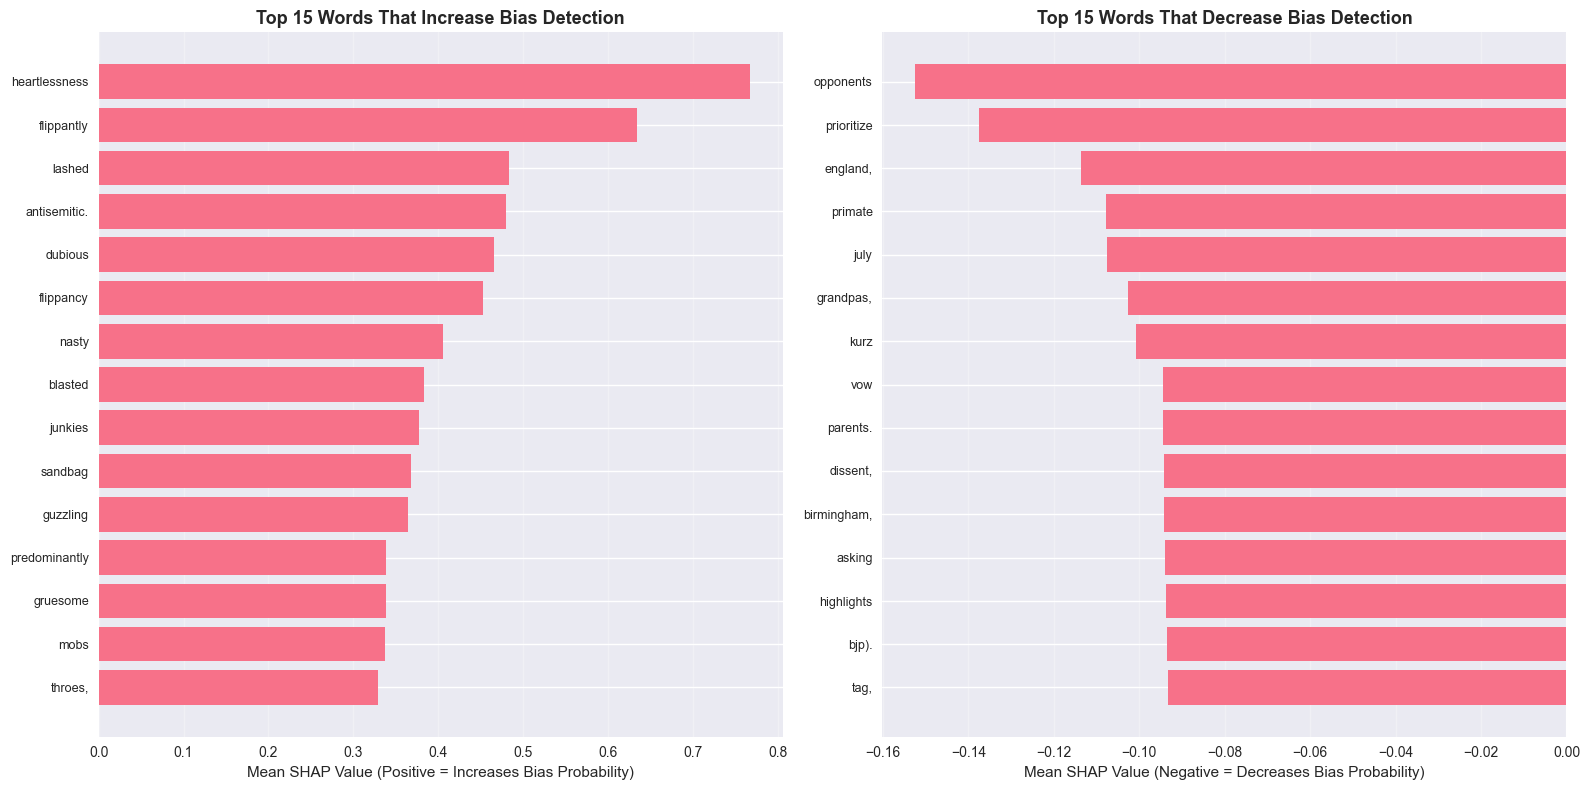

In [22]:
# Visualize top bias indicators
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Positive indicators
top_pos_plot = top_positive.head(15)
axes[0].barh(range(len(top_pos_plot)), top_pos_plot['mean_shap'].values)
axes[0].set_yticks(range(len(top_pos_plot)))
axes[0].set_yticklabels([w[:50] + '...' if len(w) > 50 else w for w in top_pos_plot['word']], fontsize=9)
axes[0].set_xlabel('Mean SHAP Value (Positive = Increases Bias Probability)', fontsize=11)
axes[0].set_title('Top 15 Words That Increase Bias Detection', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Negative indicators
top_neg_plot = top_negative.head(15)
axes[1].barh(range(len(top_neg_plot)), top_neg_plot['mean_shap'].values)
axes[1].set_yticks(range(len(top_neg_plot)))
axes[1].set_yticklabels([w[:50] + '...' if len(w) > 50 else w for w in top_neg_plot['word']], fontsize=9)
axes[1].set_xlabel('Mean SHAP Value (Negative = Decreases Bias Probability)', fontsize=11)
axes[1].set_title('Top 15 Words That Decrease Bias Detection', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/top_bias_indicators{model_suffix}.png', dpi=300, bbox_inches='tight')
plt.show()


## Analysis 2: Comparison by Prediction Type (TP, FP, TN)


In [23]:
# Research Question 6: How do attributions differ between TP, FP, TN?

# Classify samples
shap_df['pred_type'] = shap_df.apply(
    lambda row: 'TP' if row['gold'] == 1 and row['pred'] == 1 else
                 'FP' if row['gold'] == 0 and row['pred'] == 1 else
                 'TN' if row['gold'] == 0 and row['pred'] == 0 else 'FN',
    axis=1
)

# Extract word-level attributions for each type
def extract_word_attribs_by_type(df, pred_type):
    word_attribs = []
    for _, row in df[df['pred_type'] == pred_type].iterrows():
        for word_attr in row['word_attribs']:
            word_attribs.append({
                'word': word_attr['word'].lower().strip(),
                'shap': word_attr['shap'],
                'abs_shap': abs(word_attr['shap']),
                'type': pred_type
            })
    return pd.DataFrame(word_attribs)

tp_words = extract_word_attribs_by_type(shap_df, 'TP')
fp_words = extract_word_attribs_by_type(shap_df, 'FP')
tn_words = extract_word_attribs_by_type(shap_df, 'TN')

print(f"True Positives: {len(tp_words)} word attributions")
print(f"False Positives: {len(fp_words)} word attributions")
print(f"True Negatives: {len(tn_words)} word attributions")


True Positives: 3246 word attributions
False Positives: 334 word attributions
True Negatives: 3210 word attributions


In [24]:
# Compare top words by type
def get_top_words(df, n=15, min_count=2):
    df_filtered = df[df.groupby('word')['word'].transform('count') >= min_count]
    return df_filtered.groupby('word').agg({
        'abs_shap': 'mean',
        'shap': 'mean',
        'word': 'count'
    }).rename(columns={'word': 'count'}).sort_values('abs_shap', ascending=False).head(n)

tp_top = get_top_words(tp_words)
fp_top = get_top_words(fp_words)
tn_top = get_top_words(tn_words)

print("=" * 60)
print("TOP WORDS IN TRUE POSITIVES (Correctly Identified Biased Text)")
print("=" * 60)
for word, row in tp_top.iterrows():
    print(f"{word[:60]:<60} | Mean |SHAP|: {row['abs_shap']:>7.4f} | Mean SHAP: {row['shap']:>7.4f} | Count: {int(row['count']):>2}")

print("\n" + "=" * 60)
print("TOP WORDS IN FALSE POSITIVES (Incorrectly Flagged as Biased)")
print("=" * 60)
for word, row in fp_top.iterrows():
    print(f"{word[:60]:<60} | Mean |SHAP|: {row['abs_shap']:>7.4f} | Mean SHAP: {row['shap']:>7.4f} | Count: {int(row['count']):>2}")

print("\n" + "=" * 60)
print("TOP WORDS IN TRUE NEGATIVES (Correctly Identified Non-Biased Text)")
print("=" * 60)
for word, row in tn_top.iterrows():
    print(f"{word[:60]:<60} | Mean |SHAP|: {row['abs_shap']:>7.4f} | Mean SHAP: {row['shap']:>7.4f} | Count: {int(row['count']):>2}")


TOP WORDS IN TRUE POSITIVES (Correctly Identified Biased Text)
claimed                                                      | Mean |SHAP|:  0.2653 | Mean SHAP:  0.2653 | Count:  3
bizarre                                                      | Mean |SHAP|:  0.2441 | Mean SHAP:  0.2441 | Count:  2
ideology                                                     | Mean |SHAP|:  0.2085 | Mean SHAP:  0.2085 | Count:  2
called                                                       | Mean |SHAP|:  0.1959 | Mean SHAP:  0.1959 | Count:  3
mockery                                                      | Mean |SHAP|:  0.1810 | Mean SHAP:  0.1810 | Count:  2
claiming                                                     | Mean |SHAP|:  0.1800 | Mean SHAP:  0.1800 | Count:  2
claim                                                        | Mean |SHAP|:  0.1696 | Mean SHAP:  0.1696 | Count:  4
conspiracy                                                   | Mean |SHAP|:  0.1590 | Mean SHAP:  0.1590 | Count:  2
l

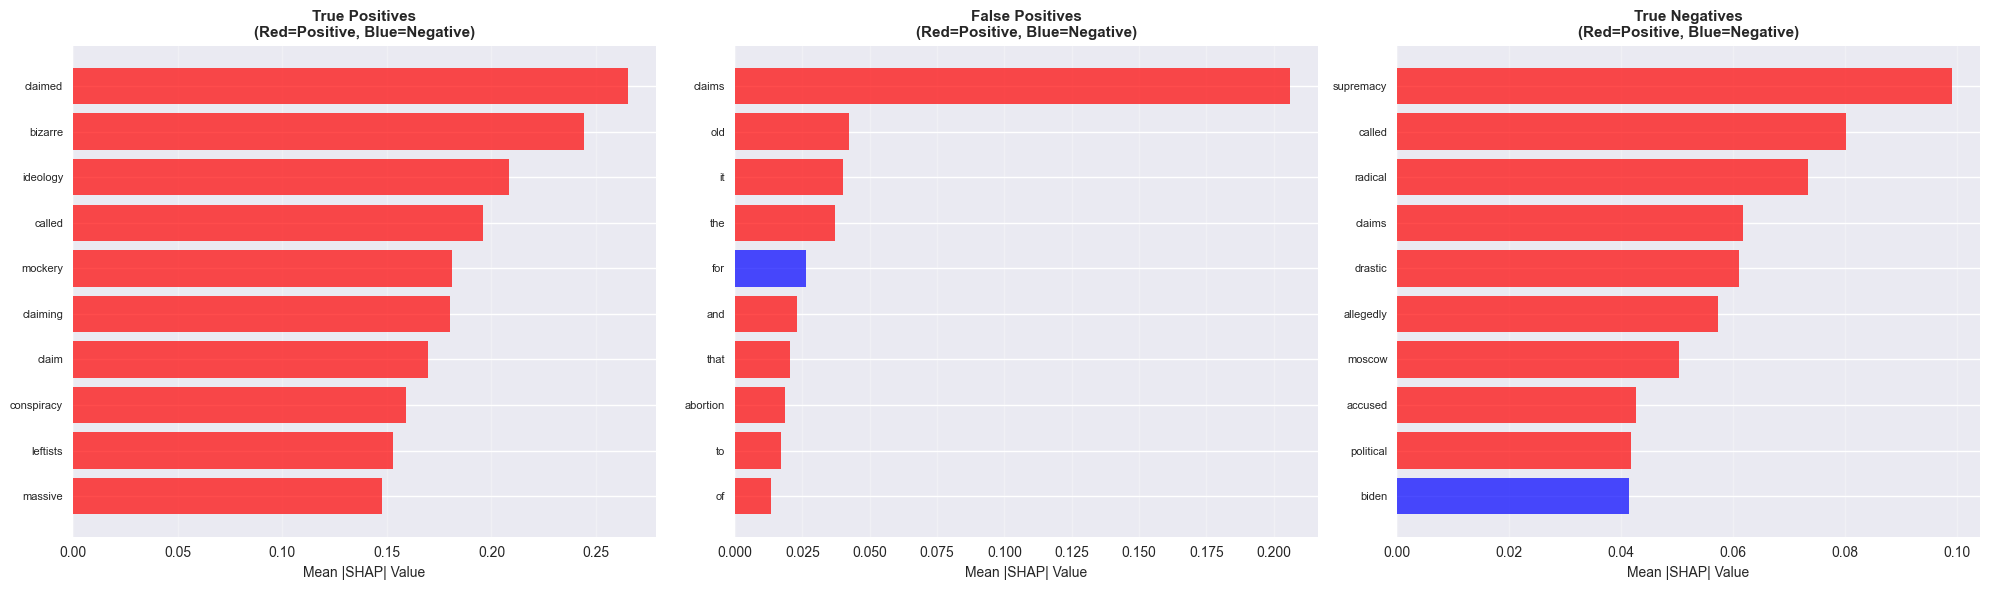

In [25]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (df, title, ax) in enumerate(zip(
    [tp_top, fp_top, tn_top],
    ['True Positives', 'False Positives', 'True Negatives'],
    axes
)):
    top_15 = df.head(10)
    colors = ['red' if x > 0 else 'blue' for x in top_15['shap'].values]
    ax.barh(range(len(top_15)), top_15['abs_shap'].values, color=colors, alpha=0.7)
    ax.set_yticks(range(len(top_15)))
    ax.set_yticklabels([w[:40] + '...' if len(w) > 40 else w for w in top_15.index], fontsize=8)
    ax.set_xlabel('Mean |SHAP| Value', fontsize=10)
    ax.set_title(f'{title}\n(Red=Positive, Blue=Negative)', fontsize=11, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/comparison_by_type{model_suffix}.png', dpi=300, bbox_inches='tight')
plt.show()


## Analysis 3: SHAP Value Distribution by Prediction Type


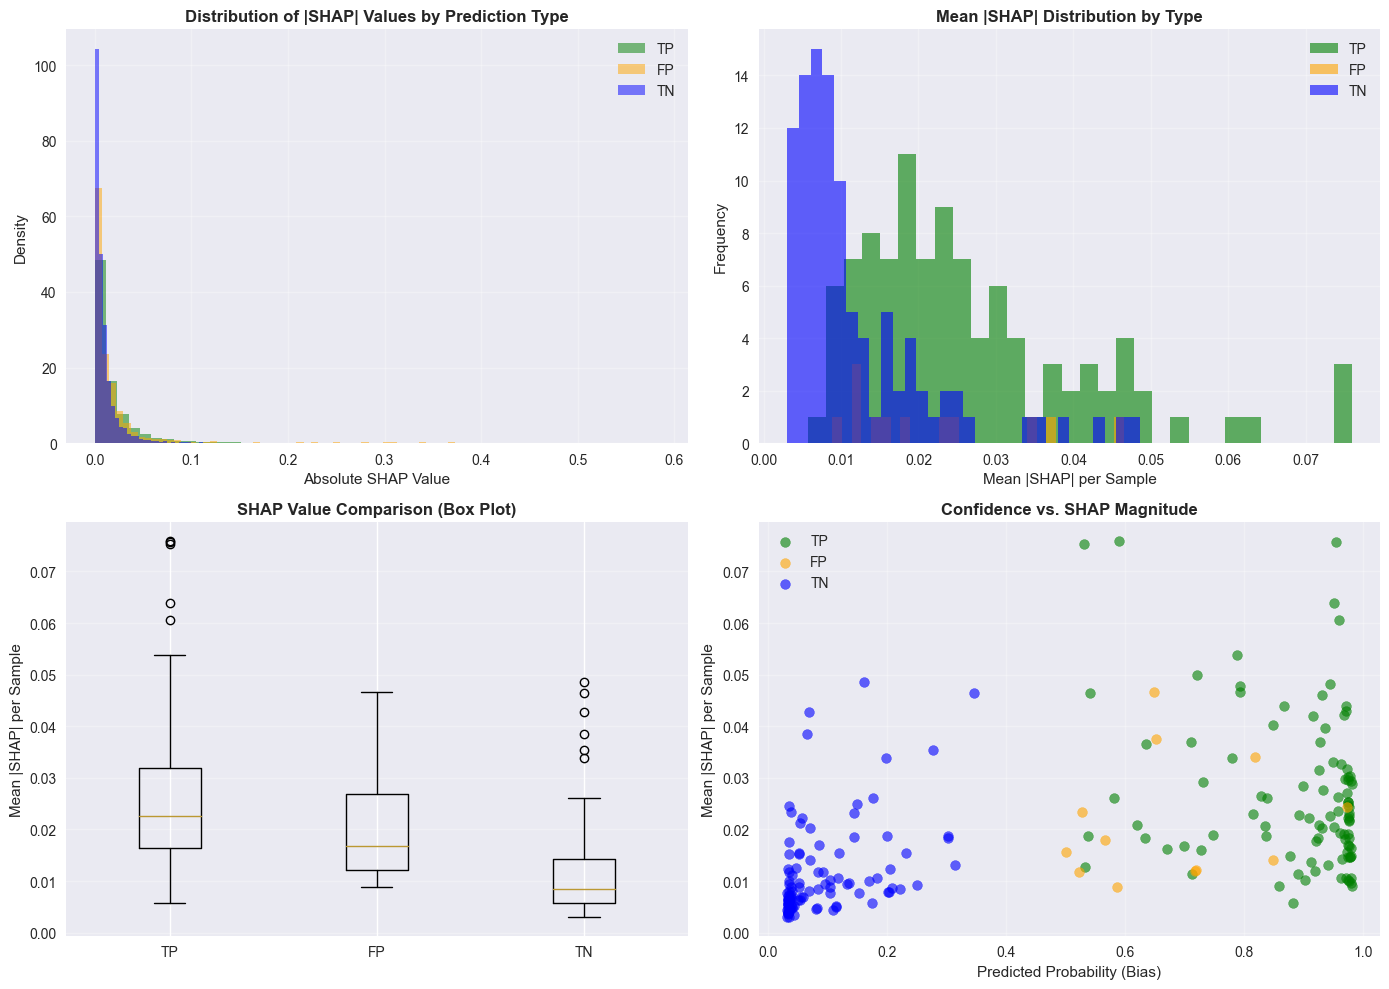

In [26]:
# Compare SHAP value distributions
shap_df['mean_abs_shap'] = shap_df['shap_pos'].apply(lambda x: np.mean([abs(v) for v in x]))
shap_df['mean_shap'] = shap_df['shap_pos'].apply(lambda x: np.mean(x))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of absolute SHAP values
for pred_type, color in [('TP', 'green'), ('FP', 'orange'), ('TN', 'blue')]:
    type_df = shap_df[shap_df['pred_type'] == pred_type]
    all_shap = []
    for _, row in type_df.iterrows():
        all_shap.extend([abs(x) for x in row['shap_pos']])
    axes[0, 0].hist(all_shap, bins=50, alpha=0.5, label=pred_type, color=color, density=True)

axes[0, 0].set_xlabel('Absolute SHAP Value', fontsize=11)
axes[0, 0].set_ylabel('Density', fontsize=11)
axes[0, 0].set_title('Distribution of |SHAP| Values by Prediction Type', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Mean SHAP per sample
for pred_type, color in [('TP', 'green'), ('FP', 'orange'), ('TN', 'blue')]:
    type_df = shap_df[shap_df['pred_type'] == pred_type]
    axes[0, 1].hist(type_df['mean_abs_shap'], bins=30, alpha=0.6, label=pred_type, color=color)

axes[0, 1].set_xlabel('Mean |SHAP| per Sample', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Mean |SHAP| Distribution by Type', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Box plot comparison
data_for_box = []
for pred_type in ['TP', 'FP', 'TN']:
    type_df = shap_df[shap_df['pred_type'] == pred_type]
    data_for_box.append(type_df['mean_abs_shap'].values)

axes[1, 0].boxplot(data_for_box, labels=['TP', 'FP', 'TN'])
axes[1, 0].set_ylabel('Mean |SHAP| per Sample', fontsize=11)
axes[1, 0].set_title('SHAP Value Comparison (Box Plot)', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Prediction confidence vs SHAP magnitude
for pred_type, color in [('TP', 'green'), ('FP', 'orange'), ('TN', 'blue')]:
    type_df = shap_df[shap_df['pred_type'] == pred_type]
    axes[1, 1].scatter(type_df['prob_pos'], type_df['mean_abs_shap'], 
                       alpha=0.6, label=pred_type, color=color, s=50)

axes[1, 1].set_xlabel('Predicted Probability (Bias)', fontsize=11)
axes[1, 1].set_ylabel('Mean |SHAP| per Sample', fontsize=11)
axes[1, 1].set_title('Confidence vs. SHAP Magnitude', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/shap_distributions{model_suffix}.png', dpi=300, bbox_inches='tight')
plt.show()


## Analysis 4: Summary Statistics and Key Findings


In [27]:
# Generate summary report
print("=" * 80)
print("SUMMARY STATISTICS AND KEY FINDINGS")
print("=" * 80)

print("\n1. PREDICTION ACCURACY BY TYPE:")
print("-" * 80)
pred_counts = shap_df['pred_type'].value_counts()
for ptype, count in pred_counts.items():
    print(f"  {ptype}: {count} samples ({count/len(shap_df)*100:.1f}%)")

print("\n2. SHAP VALUE STATISTICS:")
print("-" * 80)
print(f"  Overall mean |SHAP|: {shap_df['mean_abs_shap'].mean():.4f}")
print(f"  Overall std |SHAP|: {shap_df['mean_abs_shap'].std():.4f}")
for ptype in ['TP', 'FP', 'TN']:
    type_df = shap_df[shap_df['pred_type'] == ptype]
    if len(type_df) > 0:
        print(f"  {ptype} mean |SHAP|: {type_df['mean_abs_shap'].mean():.4f} (std: {type_df['mean_abs_shap'].std():.4f})")

print("\n3. TOP 5 GLOBAL BIAS INDICATORS:")
print("-" * 80)
top_5_global = global_importance.head(5)
for idx, row in top_5_global.iterrows():
    print(f"  {idx+1}. {row['word'][:70]}")
    print(f"     Mean |SHAP|: {row['mean_abs_shap']:.4f}, Count: {int(row['count'])}")

print("\n4. FALSE POSITIVE ANALYSIS:")
print("-" * 80)
fp_df = shap_df[shap_df['pred_type'] == 'FP']
if len(fp_df) > 0:
    print(f"  Number of FPs: {len(fp_df)}")
    print(f"  Mean confidence: {fp_df['prob_pos'].mean():.3f}")
    print(f"  Mean |SHAP|: {fp_df['mean_abs_shap'].mean():.4f}")
    print(f"  \n  Sample FP texts:")
    for i, (_, row) in enumerate(fp_df.head(3).iterrows()):
        print(f"    {i+1}. {row['text'][:100]}...")

print("\n" + "=" * 80)
print("Analysis complete! Check the generated plots in the outputs directory.")
print("=" * 80)


SUMMARY STATISTICS AND KEY FINDINGS

1. PREDICTION ACCURACY BY TYPE:
--------------------------------------------------------------------------------
  TP: 100 samples (47.2%)
  TN: 100 samples (47.2%)
  FP: 12 samples (5.7%)

2. SHAP VALUE STATISTICS:
--------------------------------------------------------------------------------
  Overall mean |SHAP|: 0.0193
  Overall std |SHAP|: 0.0144
  TP mean |SHAP|: 0.0266 (std: 0.0150)
  FP mean |SHAP|: 0.0215 (std: 0.0120)
  TN mean |SHAP|: 0.0117 (std: 0.0093)

3. TOP 5 GLOBAL BIAS INDICATORS:
--------------------------------------------------------------------------------
  1. heartlessness
     Mean |SHAP|: 0.7673, Count: 1
  2. flippantly
     Mean |SHAP|: 0.6344, Count: 1
  3. lashed
     Mean |SHAP|: 0.4837, Count: 1
  4. antisemitic.
     Mean |SHAP|: 0.4799, Count: 1
  5. dubious
     Mean |SHAP|: 0.4656, Count: 1

4. FALSE POSITIVE ANALYSIS:
--------------------------------------------------------------------------------
  Number of 

## Suggested Research Paper Structure

Based on the analyses above, here's a suggested structure for your ACL workshop paper:

### Title Suggestion:
**"What Makes a Text Biased? A SHAP-based Analysis of Bias Detection Models"**

### Abstract:
- Brief overview of bias detection models
- Use of SHAP for interpretability
- Key findings about what features drive bias detection

### 1. Introduction
- Motivation: Understanding bias detection is crucial for fairness
- Research questions
- Contributions

### 2. Related Work
- Bias detection in NLP
- Model interpretability (SHAP, LIME, etc.)
- Fairness in NLP

### 3. Methodology
- Dataset (BABE)
- Model (bias-detector)
- SHAP analysis setup
- Analysis framework

### 4. Findings
#### 4.1 Lexical Patterns
- Top bias indicators
- Word-level analysis

#### 4.2 Prediction Type Analysis
- TP vs FP vs TN patterns
- What distinguishes correct from incorrect predictions

#### 4.3 Spurious Correlations
- Named entity reliance
- Potential biases in the model itself

#### 4.4 Contextual vs Lexical Signals
- Word co-occurrence patterns
- Contextual understanding

### 5. Discussion
- Implications for bias detection
- Model limitations
- Recommendations for improvement

### 6. Conclusion
- Summary of findings
- Future work

### References
